## Malaria Cell Object Detection and Classification with PyTorch
This notebook demonstrates how to prepare the malaria cell dataset for object detection and classification, set up a PyTorch Dataset and DataLoader, train a Faster R-CNN model, and visualize bounding boxes and predictions.

For more on the original Fast R-CNN architecture, see the papers: 

[Fast R-CNN (Girshick, Microsoft Research, 2015)](https://arxiv.org/abs/1504.08083) 

[Faster R-CNN: Towards Real-Time Object Detection with Region Proposal Networks (Shaoqing Ren, Kaiming He, Ross Girshick, and Jian Sun, 2016)](https://arxiv.org/abs/1506.01497)

[Benchmarking Detection Transfer Learning with Vision Transformers (Yanghao Li Saining Xie Xinlei Chen Piotr Doll´ar Kaiming He Ross Girshick,  Facebook AI Research (FAIR), 2021 )](https://arxiv.org/abs/2111.11429)


This notebook is designed to tackle the challenge of automated malaria cell detection in microscopic blood smear images, using the P. vivax malaria dataset from Kaggle (https://www.kaggle.com/datasets/orvile/p-vivax-malaria-infected-human-blood-smears). By leveraging annotated images and advanced deep learning techniques, the workflow guides you through:

- Loading and preprocessing annotated cell data (including bounding boxes and cell categories) from JSON files.
- Building a robust PyTorch Dataset and DataLoader tailored for object detection tasks.
- Addressing class imbalance through weighted loss functions and oversampling strategies.
- Training a state-of-the-art Faster R-CNN model to accurately detect and classify different cell types, such as red blood cells, trophozoites, rings, difficults, schizonts, gametocytes, and leukocytes.
- Evaluating model performance with precision, recall, F1 score, ROC curves, and confusion matrices.
- Visualizing both ground truth and predicted bounding boxes to interpret model predictions.

The ultimate goal is to provide a reproducible pipeline for malaria cell detection that can support research in automated disease diagnosis and aid in the development of AI-powered medical tools.

In [1]:
# Install required packages if not already installed
import sys
#!{sys.executable} -m pip install torch torchvision matplotlib pillow tqdm
import json
from pathlib import Path
import numpy as np
import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt
from torch.utils.data import WeightedRandomSampler

### Check CUDA availability and PyTorch version
This cell prints the versions of PyTorch and torchvision, checks if CUDA is available, and displays information about the available GPU devices.

It also lists available Faster R-CNN models in torchvision. This helps verify your environment is set up correctly for training deep learning models with GPU acceleration.

In [2]:
print(torchvision.__version__)
import torchvision.models.detection as detection
print([fn for fn in dir(detection) if fn.startswith("fasterrcnn")])
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Number of GPUs:", torch.cuda.device_count())
print("Current device:", torch.cuda.current_device())
print("Device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

0.22.0+cu118
['fasterrcnn_mobilenet_v3_large_320_fpn', 'fasterrcnn_mobilenet_v3_large_fpn', 'fasterrcnn_resnet50_fpn', 'fasterrcnn_resnet50_fpn_v2']
PyTorch version: 2.7.0+cu118
CUDA available: True
Number of GPUs: 1
Current device: 0
Device name: NVIDIA GeForce RTX 4060 Laptop GPU


### Configuration Enums and Training Parameters

This cell defines several enums to manage configuration options for the training pipeline, such as run mode (training, Bayesian optimization, or testing), loss function type, and model architecture. 

It also sets up key training parameters, including the output folder for model checkpoints and the number of training epochs.

In [3]:
from enum import Enum, auto

class RunMode(Enum):
    TRAIN = auto()
    BAYESIAN_OPTIMIZATION = auto()
    TEST = auto()

class LossFunction(Enum):
    WEIGHTED_CROSS_ENTROPY = auto()
    WEIGHTED_FOCAL = auto()

class ModelType(Enum):
    FASTERRCNN_RESNET50_FPN = auto()
    FASTERRCNN_RESNET50_FPN_V2 = auto()

run_mode = RunMode.TRAIN
loss_function = LossFunction.WEIGHTED_CROSS_ENTROPY
model_type = ModelType.FASTERRCNN_RESNET50_FPN

model_folder = Path("faster_rcnn_resnet50_fpn_weighted_CE_loss")
model_folder.mkdir(exist_ok=True)

num_epochs = 60

### Prepare Dataset for Object Detection and Classification
Convert the JSON data into a PyTorch Dataset compatible with torchvision's Faster R-CNN.

This section defines the `MalariaCellDataset` class, which converts annotated malaria cell data from JSON format into a PyTorch `Dataset` suitable for object detection and classification tasks. 

The dataset loads images and their corresponding bounding boxes and labels, applies optional data augmentations, and returns data in the format expected by torchvision's Faster R-CNN models.

- **CATEGORY_MAP**: Maps cell category names to integer labels.
- **MalariaCellDataset**: Loads images and annotations, applies transformations, and returns image tensors and target dictionaries containing bounding boxes and labels for each object in the image. This enables seamless integration with PyTorch's object detection pipelines.

In [4]:
CATEGORY_MAP = {
    'red blood cell': 1,
    'trophozoite': 2,
    'ring': 3,
    'difficult': 4,
    'schizont': 5,
    'gametocyte': 6,
    'leukocyte': 7
}

class MalariaCellDataset(Dataset):
    def __init__(self, data, images_dir, transforms=None):
        self.data = data
        self.images_dir = Path(images_dir)
        self.transforms = transforms

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        img_path = self.images_dir / Path(item['image']['pathname']).name
        img = Image.open(img_path).convert('RGB')
        boxes = []
        labels = []
        for obj in item['objects']:
            bbox = obj['bounding_box']
            xmin = bbox['minimum']['c']
            ymin = bbox['minimum']['r']
            xmax = bbox['maximum']['c']
            ymax = bbox['maximum']['r']
            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(CATEGORY_MAP[obj['category']])
        boxes_np = np.array(boxes, dtype=np.float32)
        labels_np = np.array(labels, dtype=np.int64)
        target = {
            'boxes': torch.as_tensor(boxes, dtype=torch.float32),
            'labels': torch.as_tensor(labels, dtype=torch.int64)
        }
        if self.transforms:
            transformed = self.transforms(
                image=np.array(img),
                bboxes=boxes_np,
                labels=labels_np
            )
            img = transformed['image']
            # Update target with transformed bboxes/labels
            target['boxes'] = torch.as_tensor(transformed['bboxes'], dtype=torch.float32)
            target['labels'] = torch.as_tensor(transformed['labels'], dtype=torch.int64)
        else:
            img = torchvision.transforms.functional.to_tensor(img)
        return img, target

### Malaria Data Loading and Visualization
This section shows how the malaria cell image data is loaded and prepared for analysis. It also explains how the different types of cells are counted and how we can check if the dataset is balanced. 

By visualizing the number of each cell type, we can better understand the data before training the AI model.

In [5]:
class MalariaDataLoader:
    def __init__(self, images_dir="images"):
        self.images_dir = images_dir


    def load_dataset(self, json_file):
        with open(json_file, 'r') as f:
            data = json.load(f)
        return data


    @staticmethod
    def collate_fn(batch):
        return tuple(zip(*batch))


    def get_data_loader(self, json_file, batch_size=2, transforms=None):
        data = self.load_dataset(json_file)
        print(f'Total Images: {len(data)}')

        dataset = MalariaCellDataset(data, images_dir=self.images_dir, transforms=transforms)
        print(f'Dataset size: {len(dataset)}')
        img, target = dataset[0]

        if isinstance(img, torch.Tensor):
            print('Image shape:', img.shape)
        else:
            print('Image shape:', np.array(img).shape)

        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False, collate_fn=self.collate_fn)
        batch = next(iter(dataloader))
        print('Batch loaded. Number of images:', len(batch[0]))

        return dataset, dataloader


    def get_class_distribution(self, dataset):
        """Count the number of instances for each class in the dataset."""
        # Count class frequencies
        class_counts = {k: 0 for k in CATEGORY_MAP if k != 'background'}
        for i in range(len(dataset)):
            _, target = dataset[i]
            labels = target['labels'].cpu().numpy()
            for label in labels:
                class_name = [k for k, v in CATEGORY_MAP.items() if v == label and k != 'background']
                if class_name:
                    class_counts[class_name[0]] += 1

        total = sum(class_counts.values())
        class_weights = [total / c if c > 0 else 0.0 for c in class_counts.values()]
        return class_counts, class_weights
    

    def get_oversampled_data_loader(self, json_file, batch_size=2, transforms=None):
        data = self.load_dataset(json_file)
        print(f'Total Images: {len(data)}')
        dataset = MalariaCellDataset(data, images_dir=self.images_dir, transforms=transforms)
        class_counts, class_weights = self.get_class_distribution(dataset)
        print('Class counts:', class_counts, 'Class weights:', class_weights)

        # Compute sample weights (inverse of class frequency for the first label in each sample)
        sample_weights = []
        for i in range(len(dataset)):
            _, target = dataset[i]
            labels = target['labels'].cpu().numpy()
            if len(labels) > 0:
                label = labels[0]
                class_name = [k for k, v in CATEGORY_MAP.items() if v == int(label) and k != 'background']
                if class_name and class_name[0] in class_counts:
                    weight = 1.0 / (class_counts[class_name[0]] + 1e-6)
                else:
                    weight = 1.0
            else:
                weight = 1.0
            sample_weights.append(weight)

        # Normalize weights so their sum equals the number of images
        sum_weights = sum(sample_weights)
        sample_weights = [w * len(sample_weights) / sum_weights for w in sample_weights]
        sampler = WeightedRandomSampler(sample_weights, num_samples=len(dataset), replacement=True)
        data_loader = DataLoader(dataset, batch_size=batch_size, sampler=sampler, collate_fn=self.collate_fn)
        return dataset, sampler, data_loader


class MalariaDataVisualizer:
    @staticmethod
    def plot_class_distribution(class_counts, type_of_data="Training"):
        """Plot the class distribution."""
        plt.figure(figsize=(10, 6))
        bars = plt.bar(class_counts.keys(), class_counts.values(), color='blue')
        for bar, count in zip(bars, class_counts.values()):
            plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(count), ha='center', va='bottom', fontsize=10)
        plt.xlabel('Class')
        plt.ylabel('Count')
        plt.title(f'Class Distribution in {type_of_data.capitalize()} Data')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()


    @staticmethod
    def plot_oversampled_class_distribution(dataset, image_sampler):
        """Plot the class distribution after oversampling."""
        image_weights = list(image_sampler.weights)
        sampled_indices = list(image_sampler)[:10]
        sampled_filenames = [dataset.data[i]['image']['pathname'] for i in sampled_indices]
        print("Sampled image filenames:", sampled_filenames)
        print("\nSampled image indices:", sampled_indices)
        print("\nSampled image weights:", [image_weights[i] for i in sampled_indices])

        # Calculate total probability mass assigned to each class by summing image weights for images containing that class
        class_prob_mass = {k: 0.0 for k in CATEGORY_MAP if k != 'background'}
        for img_idx in range(len(dataset)):
            _, target = dataset[img_idx]
            labels = set(target['labels'].cpu().numpy())
            for label in labels:
                class_name = [k for k, v in CATEGORY_MAP.items() if v == label and k != 'background']
                if class_name:
                    class_prob_mass[class_name[0]] += image_weights[img_idx]

        # Normalize to get probability distribution
        total_mass = sum(class_prob_mass.values())
        class_probs = {k: (class_prob_mass[k] / total_mass if total_mass > 0 else 0) for k in class_prob_mass}

        # Plot
        plt.figure(figsize=(8, 4))
        plt.bar(
            list(class_probs.keys()),
            list(class_probs.values()),
            color='orange'
        )
        plt.ylabel('Probability Mass (Normalized)')
        plt.xlabel('Class')
        plt.title('Class Distribution Based on Oversampling Weights')
        plt.xticks(rotation=30)
        plt.tight_layout()
        plt.show()

### Data Augmentation and DataLoader Preparation

This section sets up how the Faster R-CNN model learns from malaria cell images. 

It uses data augmentation techniques to slightly change the images each time, such as flipping or brightening them, so the model can learn to recognize malaria cells in many different situations. 

This helps the model become more accurate and reliable. The code also prepares the images and their labels in a way that makes it easy for the computer to use them for learning and testing.

In [6]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

malaria_data_loader = MalariaDataLoader(images_dir="images")


# Define transformations for training dataset
train_transformations = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Affine(translate_percent=0.05, scale=(0.9, 1.1), rotate=(-15, 15), p=0.5),
    A.HueSaturationValue(p=0.3),
    A.Blur(blur_limit=3, p=0.2),
    A.GaussNoise(p=0.2),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels']))

train_dataset, train_data_loader = malaria_data_loader.get_data_loader(json_file='training.json', batch_size=2, transforms=train_transformations)

train_oversampled_dataset, train_data_sampler, train_oversampled_data_loader = malaria_data_loader.get_oversampled_data_loader(json_file='training.json', batch_size=2, transforms=train_transformations)

Total Images: 1208
Dataset size: 1208
Image shape: torch.Size([3, 1200, 1600])
Batch loaded. Number of images: 2
Total Images: 1208
Class counts: {'red blood cell': 76782, 'trophozoite': 1470, 'ring': 351, 'difficult': 440, 'schizont': 179, 'gametocyte': 144, 'leukocyte': 102} Class weights: [1.034982157276445, 54.05986394557823, 226.4045584045584, 180.6090909090909, 443.9553072625698, 551.8611111111111, 779.0980392156863]


In [7]:
# Define transformations for test dataset
test_transformations = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels']))

test_dataset, test_data_loader = malaria_data_loader.get_data_loader(json_file='test.json', batch_size=2, transforms=test_transformations)

Total Images: 120
Dataset size: 120
Image shape: torch.Size([3, 1383, 1944])
Batch loaded. Number of images: 2


C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\albumentations\core\composition.py:331: UserWarning: Got processor for bboxes, but no transform to process it.
  self._set_keys()


### Explore Class Distribution of Training Data
This section shows how we check the number of each type of malaria cell in the training data. 

By looking at these counts, we can see if some cell types are much more common than others, like we can see in the bar chart below that distribution of the red blood cells is much higher than the other cell types. 

This helps us understand if our model might need extra help to learn about rare cell types, so it can make fair and accurate predictions for all categories.

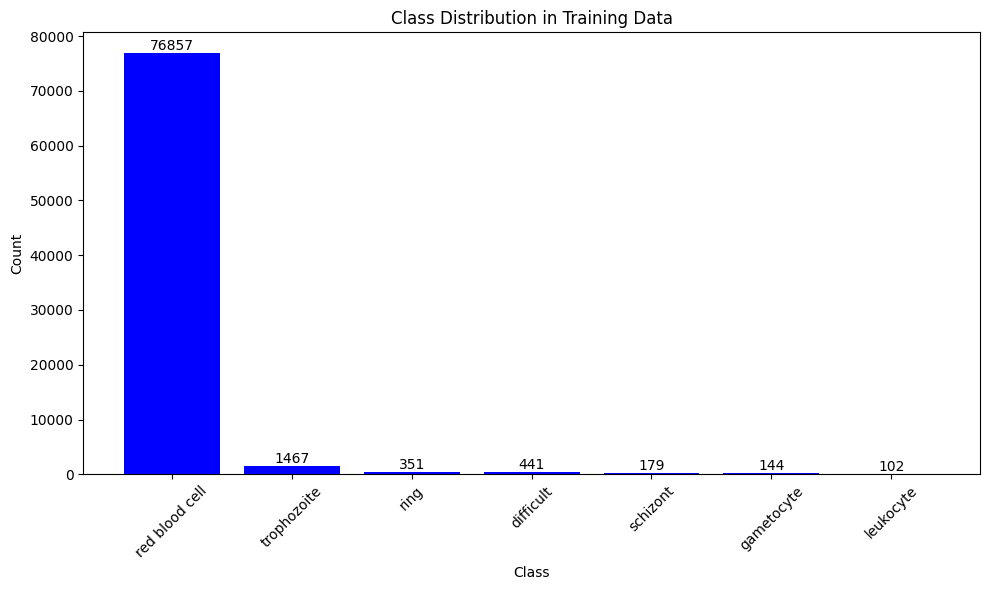

In [8]:
if run_mode == RunMode.TRAIN:
    # Plot training data class distribution
    training_data_class_distribution, _ = malaria_data_loader.get_class_distribution(train_dataset)
    MalariaDataVisualizer.plot_class_distribution(training_data_class_distribution, type_of_data="Training")

### Visualize teh Class Distribution in Oversampled Training Dataset

This section shows how the training data is adjusted to give more attention to rare cell types. 

By using a special technique called "oversampling," the model gets to see less common malaria cell types more often during training. 

The bar chart below helps us see how this balancing works, making sure the model learns about all cell types fairly, not just the most common ones.

**Note:** After oversampling the distribiution/weight of cell types is as below:

Class counts: {'red blood cell': 76888, 'trophozoite': 1471, 'ring': 352, 'difficult': 439, 'schizont': 179, 'gametocyte': 144, 'leukocyte': 103} 

Class weights: [1.0349599417334305, 54.09653297076819, 226.0681818181818, 181.26651480637813, 444.5586592178771, 552.6111111111111, 772.5825242718447]

As you can see the distribution of red blood cells still remains high as compared to the other blood cells. This is because, even though the images with the lower number of classes are given more weight by the oversampling algorithm, the sampled images still contain propotinally large number of red blood cells.

As a result, the dataset still have unbalanced class distribution. To perfectly balance this type of dataset, it is recomended that the images with the lower number of classes should be manually cropped to keep the rare classes but reduce the number of red blood cells and the bounding boxes in the cropped images should be labelled appropiately. 

Sampled image filenames: ['/images/441d7843-b20b-4c10-84e3-e6d32621e880.png', '/images/fbb1b44c-d75a-4550-a6c0-0eb62b96bfce.png', '/images/28c96a4a-4549-4761-99e4-ace4ea7e7ac9.png', '/images/f09acb0c-b270-4e91-99f8-410adfa7f34a.png', '/images/fbb1b44c-d75a-4550-a6c0-0eb62b96bfce.png', '/images/003a89b0-a095-417a-8dd6-f408339bbc68.png', '/images/1dd3e6dd-343f-4cc9-b0ed-e4d27fb36f0a.png', '/images/1dd3e6dd-343f-4cc9-b0ed-e4d27fb36f0a.png', '/images/5a043d69-f435-46d4-8691-395c1602a76a.png', '/images/93f40356-5676-45d3-8e83-8028708c93ba.png']

Sampled image indices: [526, 394, 764, 59, 394, 588, 733, 733, 196, 788]

Sampled image weights: [tensor(0.1933, dtype=torch.float64), tensor(33.7396, dtype=torch.float64), tensor(82.9353, dtype=torch.float64), tensor(42.2947, dtype=torch.float64), tensor(33.7396, dtype=torch.float64), tensor(82.9353, dtype=torch.float64), tensor(82.9353, dtype=torch.float64), tensor(82.9353, dtype=torch.float64), tensor(103.0932, dtype=torch.float64), tensor(103.09

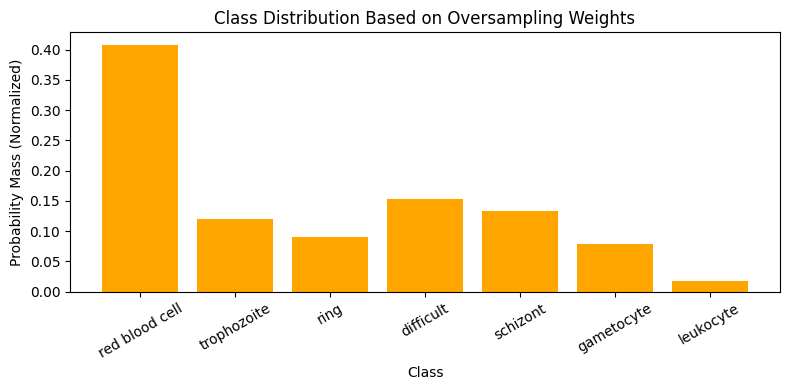

In [9]:
if run_mode == RunMode.TRAIN:
    # Plot oversampled training data class distribution
    MalariaDataVisualizer.plot_oversampled_class_distribution(train_oversampled_dataset, train_data_sampler)

### Explore Class Distribution of Test Data

This section checks how many examples of each malaria cell type are present in the test data. By looking at these numbers, we can see if some cell types are much more common than others in the test set. 

A bar chart is shown to help us easily compare the counts of each cell type. This helps us understand how well the test data represents all the different types of malaria cells, and whether our model will be tested fairly on both common and rare cell types.

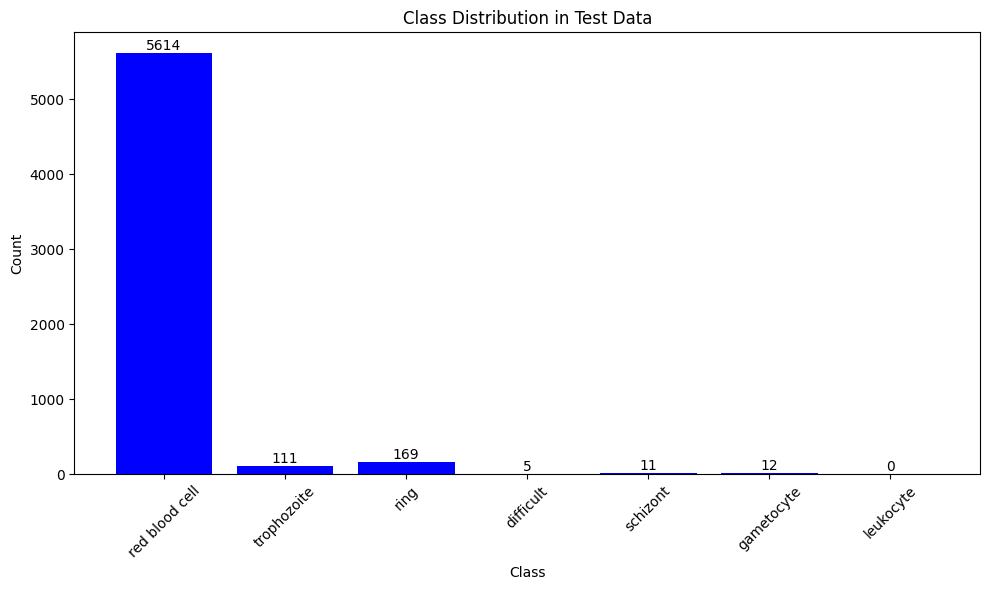

In [10]:
# Plot test data class distribution
test_data_class_distribution, _ = malaria_data_loader.get_class_distribution(test_dataset)
MalariaDataVisualizer.plot_class_distribution(test_data_class_distribution, type_of_data="Test")

### Fast R-CNN Weighted Predictor for Fast R-CNN Model
This section introduces a special part of the AI model called the "Weighted Predictor." It helps the model pay more attention to rare malaria cell types by giving them extra importance during training. 

This makes the model better at finding and recognizing all types of malaria cells, not just the most common ones. By using this approach, the AI can make more balanced and fair predictions, which is especially important in medical diagnosis where every cell type matters.

You can find the implementation of the `WeightedFastRCNNPredictor` class in the code section below, which extends the standard Fast R-CNN predictor to support weighted loss functions. 

For more on the original Fast R-CNN architecture, see the papers: 

[Fast R-CNN (Girshick, Microsoft Research, 2015)](https://arxiv.org/abs/1504.08083) 

[Faster R-CNN: Towards Real-Time Object Detection with Region Proposal Networks (Shaoqing Ren, Kaiming He, Ross Girshick, and Jian Sun, 2016)](https://arxiv.org/abs/1506.01497)

[Benchmarking Detection Transfer Learning with Vision Transformers (Yanghao Li Saining Xie Xinlei Chen Piotr Doll´ar Kaiming He Ross Girshick,  Facebook AI Research (FAIR), 2021 )](https://arxiv.org/abs/2111.11429)

Weighted Focal loss and weighted cross-entropy (CE) loss are used to address the severe class imbalance in malaria cell datasets. 

Weighted CE loss assigns higher weights to rare classes, ensuring the model does not ignore them during training. For more details on weighted cross-entropy loss, see the PyTorch documentation: [CrossEntropyLoss](https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html).

Focal loss goes further by down-weighting easy examples and focusing learning on hard, misclassified examples—this is especially useful when the majority class dominates the dataset. A custom implementation of focal loss is necessary because PyTorch's built-in loss functions do not natively support focal loss for multi-class object detection tasks. By implementing it ourselves, we can integrate class weights and tune the loss behavior to better suit the needs of malaria cell detection, resulting in a more robust and fair model. For more details on focal loss, see the original paper: [Focal Loss for Dense Object Detection (Lin et al., 2017)](https://arxiv.org/abs/1708.02002).

In [11]:
import torch.nn as nn
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights

import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean', class_weights=None):
        super().__init__()
        # Alpha should be a tensor if per-class, or a single float if balancing foreground/background
        self.alpha = alpha if alpha is not None else 0.25 # Default alpha
        self.gamma = gamma
        self.reduction = reduction
        self.class_weights = class_weights # These weights are applied inside F.cross_entropy

    def forward(self, inputs, targets):
        # inputs: raw logits [N, C]
        # targets: class indices [N]

        # Calculate CE loss without reduction
        ce_loss = F.cross_entropy(inputs, targets, weight=self.class_weights, reduction='none')

        # Get the probability of the true class
        pt = torch.exp(-ce_loss)

        # Calculate the focal term (1 - pt)^gamma
        focal_term = (1 - pt) ** self.gamma

        # Apply alpha weighting
        # alpha_t is alpha if it's the target class, and (1 - alpha) if it's not.
        # For multi-class, it's typically applied as alpha for the positive class.
        if inputs.shape[1] > 1: # Multi-class case
            # Create an alpha_t tensor that has alpha for the target class and 1-alpha for others, or just alpha for target
            # A common way for multi-class is to have alpha_t as alpha for the positive class,
            # and (1-alpha) for all other classes (negative).
            # For simplicity, if alpha is scalar, we apply it to the positive class's focal loss.
            # However, directly from the paper, alpha_t is related to balancing pos/neg *examples*.
            # For multi-class, often a scalar alpha is used for foreground classes, 1-alpha for background.
            # If `self.alpha` is a single float (like 0.25), a common way to apply it to multi-class:
            # Create a one-hot encoding of targets to select the `alpha` for positive class.
            
            # This is a common way to apply alpha_t for multi-class where targets are class indices:
            alpha_tensor = torch.ones_like(targets, dtype=inputs.dtype) * (1 - self.alpha)
            # Scatter alpha to the true class locations
            alpha_tensor = alpha_tensor.scatter_(0, targets, self.alpha)
        else: # Binary case (e.g., background vs. a single foreground class or one-vs-all)
            alpha_tensor = torch.ones_like(targets, dtype=inputs.dtype)
            alpha_tensor[targets == 1] = self.alpha
            alpha_tensor[targets == 0] = (1 - self.alpha)

        # Final Focal Loss
        focal_loss = alpha_tensor * focal_term * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else: # 'none'
            return focal_loss


class WeightedFastRCNNPredictor(FastRCNNPredictor):
    def __init__(self, in_channels, num_classes, class_weights):
        super().__init__(in_channels, num_classes)
        
        if loss_function == LossFunction.WEIGHTED_FOCAL:
            print("Using Focal Loss with class weights")
            self.cls_loss_func = FocalLoss(alpha=0.25, gamma=2.0, reduction='mean', class_weights=class_weights)
        
        elif loss_function == LossFunction.WEIGHTED_CROSS_ENTROPY:
            print("Using Weighted Cross Entropy Loss with class weights")
            self.cls_loss_func = nn.CrossEntropyLoss(weight=class_weights)

    def forward(self, x, targets=None):
        scores = self.cls_score(x)
        bbox_deltas = self.bbox_pred(x)
        return scores, bbox_deltas

    def loss(self, class_logits, labels):
        return self.cls_loss_func(class_logits, labels)

### Malaria Model Uses Fast R-CNN ResNet with Weighted Fast R-CNN Predictor
This section sets up the main AI model that will learn to find and identify malaria cells in microscope images. The model uses a powerful image recognition technique called Fast R-CNN with a ResNet backbone, which helps it spot and classify different types of cells accurately.

To make sure the model pays attention to rare cell types (not just the most common ones), it uses a special "weighted predictor." This means the model is trained to give extra importance to cell types that appear less often, helping it become fairer and more reliable for real-world malaria diagnosis. 

The code below builds this model, prepares it for training, and ensures it can use your computer's graphics card (GPU) if available for faster learning.

In [12]:
from tqdm import tqdm
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import torchvision.models.detection.faster_rcnn as faster_rcnn_models
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_V2_Weights

class MalariaModel:
    def __init__(self, dataloader, num_classes, class_weights, device):
        
        if model_type == ModelType.FASTERRCNN_RESNET50_FPN:
            print("Using Faster R-CNN with ResNet-50 FPN.")
            model = faster_rcnn_models.fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)
            in_features = model.roi_heads.box_predictor.cls_score.in_features
            model.roi_heads.box_predictor = WeightedFastRCNNPredictor(in_features, num_classes, class_weights)

        elif model_type == ModelType.FASTERRCNN_RESNET50_FPN_V2:
            print("Using Faster R-CNN with ResNet-50 FPN V2.")
            model = faster_rcnn_models.fasterrcnn_resnet50_fpn_v2(weights=FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT)
            in_features = model.roi_heads.box_predictor.cls_score.in_features
            model.roi_heads.box_predictor = WeightedFastRCNNPredictor(in_features, num_classes, class_weights)
        else:
            raise NotImplementedError("model_type is not selected.")

        self.model = model.to(device)
        self.dataloader = dataloader
        self.device = device

        if not torch.cuda.is_available() and device == 'cuda':
            raise ValueError("CUDA is not available. Please set device to 'cpu' or enable CUDA.")
        if device == 'cuda':
            if torch.cuda.device_count() > 1:
                print(f"Using {torch.cuda.device_count()} GPUs for training.")
                self.model = nn.DataParallel(self.model)
            else:
                print("Using single GPU for training.")

    def set_to_training_mode(self):
        self.model.train()
        print(f"Model set to training mode.")

    def set_to_evaluation_mode(self):
        self.model.eval()
        print(f"Model set to evaluation mode.")

    def parameters(self):
        return self.model.parameters()
    
    def state_dict(self):
        return self.model.state_dict()
    
    def save_state_dict(self, path):
        torch.save(self.model.state_dict(), path)
        #print(f"Model state dictionary saved to {path}.")
        
    def load_state_dict(self, state_dict):
        """Load model state dictionary."""
        self.model.load_state_dict(state_dict)
        #print("Model state dictionary loaded.")

    def load_from_checkpoint(self, checkpoint_path):
        checkpoint = torch.load(checkpoint_path, map_location=self.device)
        self.model.load_state_dict(checkpoint, strict=False)
        #print(f"Model state dictionary loaded from {checkpoint_path}.")

    def train(self, optimizer):
        self.model.train()
        pbar = tqdm(self.dataloader, desc='Training')
        epoch_losses = []
        for images, targets in pbar:
            images = [img.to(self.device) for img in images]
            targets = [{k: v.to(self.device) for k, v in t.items()} for t in targets]
            loss_dict = self.model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            optimizer.zero_grad()
            losses.backward()
            optimizer.step()
            epoch_losses.append(losses.item())
            pbar.set_postfix({'loss': losses.item()})

        return epoch_losses


    def evaluate(self, iou_threshold=0.5, score_threshold=0.5, max_batches=10):
        self.model.eval()

        all_true = []
        all_pred = []
        with torch.no_grad():
            for i, (images, targets) in enumerate(self.dataloader):
                if i >= max_batches:
                    break
                # Convert images to tensors and move to device
                images_tensor = [img.to(self.device) for img in images]
                outputs = self.model(images_tensor)
                for target, output in zip(targets, outputs):
                    # Filter predictions by score threshold
                    keep = output['scores'] > score_threshold
                    pred_boxes = output['boxes'][keep].cpu().numpy()
                    pred_labels = output['labels'][keep].cpu().numpy()
                    true_boxes = target['boxes'].cpu().numpy()
                    true_labels = target['labels'].cpu().numpy()
                    # For each ground truth, check if there is a matching prediction (IoU > threshold and label matches)
                    matched_pred = set()
                    for t_box, t_label in zip(true_boxes, true_labels):
                        found = False
                        for j, (p_box, p_label) in enumerate(zip(pred_boxes, pred_labels)):
                            if j in matched_pred:
                                continue
                            # Compute IoU
                            xA = max(t_box[0], p_box[0])
                            yA = max(t_box[1], p_box[1])
                            xB = min(t_box[2], p_box[2])
                            yB = min(t_box[3], p_box[3])
                            interArea = max(0, xB - xA) * max(0, yB - yA)
                            boxAArea = (t_box[2] - t_box[0]) * (t_box[3] - t_box[1])
                            boxBArea = (p_box[2] - p_box[0]) * (p_box[3] - p_box[1])
                            iou = interArea / float(boxAArea + boxBArea - interArea + 1e-6)
                            if iou > iou_threshold and t_label == p_label:
                                found = True
                                matched_pred.add(j)
                                break
                        all_true.append(1)
                        all_pred.append(1 if found else 0)
                    # False positives: predictions not matched to any ground truth
                    for j in range(len(pred_boxes)):
                        if j not in matched_pred:
                            all_true.append(0)
                            all_pred.append(1)
        precision = precision_score(all_true, all_pred, zero_division=0)
        recall = recall_score(all_true, all_pred, zero_division=0)
        f1 = f1_score(all_true, all_pred, zero_division=0)
        accuracy = accuracy_score(all_true, all_pred)
        return precision, recall, f1, accuracy
    
    def predict(self, images, score_threshold=0.5):
        self.model.eval()
        with torch.no_grad():
            images_tensor = [img.to(self.device) for img in images]
            outputs = self.model(images_tensor)
            results = []
            for output in outputs:
                keep = output['scores'] > score_threshold
                pred_boxes = output['boxes'][keep].cpu().numpy()
                pred_labels = output['labels'][keep].cpu().numpy()
                results.append({
                    'boxes': pred_boxes,
                    'labels': pred_labels,
                    'scores': output['scores'][keep].cpu().numpy()
                })
            return results
    

### Model Setup
This section prepares the AI model that will learn to find and identify malaria cells in microscope images. The model is designed to recognize different types of cells, including rare ones, by giving them extra importance during training. This helps the model become more accurate and fair, making it better at supporting real-world malaria diagnosis. The code below sets up the model so it can use your computer's graphics card (if available) for faster and more efficient learning.

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_classes = len(CATEGORY_MAP) + 1  # +1 for background

class_counts, class_weights = malaria_data_loader.get_class_distribution(train_oversampled_dataset)
# Convert class weights to a tensor
class_weights_tensor = torch.tensor([1.0] + class_weights, dtype=torch.float32)  # Add a weight for the background class (usually 1.0)

print(f"Training with {num_classes} classes and class weights: {class_weights}")
print(f'class weights tensor: {class_weights_tensor}')

malaria_training_model = MalariaModel(
    dataloader=train_oversampled_data_loader,
    num_classes=num_classes,
    class_weights=class_weights_tensor,
    device=device
)

Training with 8 classes and class weights: [1.0350039673764584, 54.09109449354181, 225.40509915014164, 180.42630385487527, 444.5139664804469, 552.5555555555555, 772.504854368932]
class weights tensor: tensor([  1.0000,   1.0350,  54.0911, 225.4051, 180.4263, 444.5140, 552.5555,
        772.5049])
Using Faster R-CNN with ResNet-50 FPN.
Using Weighted Cross Entropy Loss with class weights


### Bayesian Optimization for Hyperparameter Tuning

#### Use Bayesian Optimization to Find Optimal Hyperparameters for Efficient and Quality Training
This section uses a hyperparameter tuning technique called Bayesian Optimization to help the AI model learn better and faster. Instead of guessing the best settings for training (like how quickly the model learns or how much it should adjust its guesses), this method tries different options and learns from each attempt. By doing this, it finds the best combination of settings to make the model more accurate and efficient, saving time and improving results.

In [14]:
from skopt.space import Real
from torch.utils.data import DataLoader
from skopt import gp_minimize

import torch.optim as optim

class TorchModelWrapper:
    def __init__(self, malaria_model):
        self.malaria_model = malaria_model

    def fit(self, train_loader, lr, momentum, weight_decay, epochs=3):
        
        params = [p for p in self.malaria_model.parameters() if p.requires_grad]
        optimizer = optim.SGD(params, lr=lr, momentum=momentum, weight_decay=weight_decay)
        for _ in range(epochs):
            self.malaria_model.train(optimizer)


    def score(self):
        precision, recall, f1, accuracy = self.malaria_model.evaluate()
        return accuracy


def bayesian_optimization(train_dataset, n_iter=10):
    def objective(lr, momentum, weight_decay):
        train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=MalariaDataLoader.collate_fn)
        wrapper = TorchModelWrapper(malaria_model=malaria_training_model)
        wrapper.fit(train_loader, lr, momentum, weight_decay, epochs=2)
        return -wrapper.score()  # Negative because BayesSearchCV minimizes


    search_space = [
        Real(1e-5, 1e-2, prior='log-uniform', name='lr'),
        Real(0.7, 0.99, prior='uniform', name='momentum'),
        Real(1e-6, 1e-3, prior='log-uniform', name='weight_decay')
    ]

    result = gp_minimize(
        func=lambda params: objective(*params),
        dimensions=search_space,
        n_calls=n_iter,
        random_state=42
    )

    print("Best hyperparameters:")
    print(f"Learning rate: {result.x[0]:.6f}, Momentum: {result.x[1]:.3f}, Weight decay: {result.x[2]:.6f}")
    print(f"Best validation accuracy: {-result.fun:.4f}")
    return result

### Select Hyperparameters for Training

This section chooses the best settings for teaching the AI model, such as how quickly it learns and how much it changes with each step. If we use Bayesian Optimization, the notebook will automatically try different options and pick the best ones. Otherwise, it uses some good default values. These settings help the model learn more effectively and make better predictions. The default values used below are taken from the white paper [Benchmarking Detection Transfer Learning with Vision Transformers (Yanghao Li Saining Xie Xinlei Chen Piotr Doll´ar Kaiming He Ross Girshick,  Facebook AI Research (FAIR), 2021 )](https://arxiv.org/abs/2111.11429)

In [15]:
if run_mode == RunMode.BAYESIAN_OPTIMIZATION:
    bayesian_optimization_result = bayesian_optimization(train_oversampled_data_loader, n_iter=10)
    bo_learning_rate, bo_momentum, bo_weight_decay = bayesian_optimization_result.x
else:
    bo_learning_rate = 0.0001
    bo_momentum = 0.9
    bo_weight_decay = 0.0005

### Training Pipeline
This section shows how the AI model is trained to recognize malaria cells in microscope images. The model learns by looking at many examples and gradually improves its ability to find and identify different types of cells. During training, the model's progress is tracked using simple charts that show how well it is learning over time. After each round of learning, the model's accuracy is checked, and the best version is saved for future use. This process helps ensure the model becomes as accurate and reliable as possible for real-world malaria detection.

During training, the notebook tracks the loss value for each iteration, which shows how well the model is learning to classify and localize malaria cells. A loss curve is plotted to visualize the decrease in loss over time, helping to identify if the model is improving or if adjustments are needed.

Additionally, the Receiver Operating Characteristic (ROC) curve is plotted after training. The ROC curve illustrates the model's ability to distinguish between different cell types by plotting the true positive rate against the false positive rate at various threshold settings. The area under the ROC curve (AUC) provides a single metric to summarize the model's performance—higher values indicate better discrimination between classes. These visualizations help assess both the learning process and the final quality of the trained model.

Training: 100%|██████████| 604/604 [06:24<00:00,  1.57it/s, loss=0.91] 


Model set to evaluation mode.
Epoch 1/60,   Precision: 0.856,     Recall: 0.901, F1: 0.878,     Accuracy: 0.783,   Loss: 0.7711


Training: 100%|██████████| 604/604 [06:54<00:00,  1.46it/s, loss=0.491]


Model set to evaluation mode.
Epoch 2/60,   Precision: 0.891,     Recall: 0.925, F1: 0.908,     Accuracy: 0.831,   Loss: 0.5656


Training: 100%|██████████| 604/604 [06:47<00:00,  1.48it/s, loss=0.373]


...

Model set to evaluation mode.
Epoch 58/60,   Precision: 0.932,     Recall: 0.958, F1: 0.945,     Accuracy: 0.895,   Loss: 0.2888


Training: 100%|██████████| 604/604 [05:55<00:00,  1.70it/s, loss=0.296]


Model set to evaluation mode.
Epoch 59/60,   Precision: 0.962,     Recall: 0.960, F1: 0.961,     Accuracy: 0.925,   Loss: 0.2865


Training: 100%|██████████| 604/604 [05:54<00:00,  1.70it/s, loss=0.346]


Model set to evaluation mode.
Epoch 60/60,   Precision: 0.941,     Recall: 0.962, F1: 0.952,     Accuracy: 0.908,   Loss: 0.2794


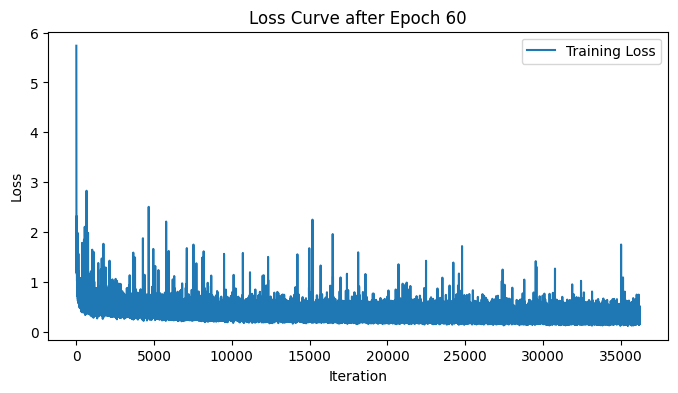

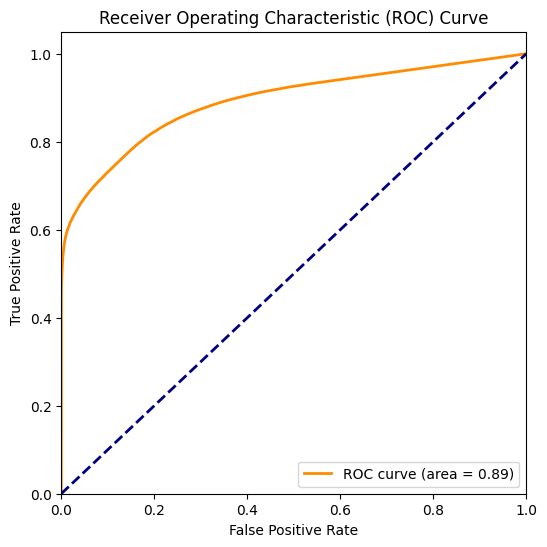

In [16]:
from sklearn.metrics import roc_curve, auc

import torch.optim as optim
import matplotlib.pyplot as plt

if run_mode == run_mode.TRAIN:
    params = [p for p in malaria_training_model.parameters() if p.requires_grad]
    optimizer = optim.SGD(params, lr=bo_learning_rate, momentum=bo_momentum, weight_decay=bo_weight_decay)

    losses_history = []

    # Store true labels and predicted scores for ROC
    all_true_labels = []
    all_pred_scores = []

    for epoch in range(num_epochs):
        epoch_losses = malaria_training_model.train(optimizer)

        # Collect predictions and true labels for ROC
        malaria_training_model.set_to_evaluation_mode()
        with torch.no_grad():
            for images, targets in train_oversampled_data_loader:
                images = [img.to(device) for img in images]
                outputs = malaria_training_model.predict(images, score_threshold=0.0)

                for target, output in zip(targets, outputs):
                    # For each class (except background), collect scores and true labels
                    for class_idx in range(1, num_classes):
                        # True: 1 if class present in target, else 0
                        true = (target['labels'].cpu().numpy() == class_idx).astype(int)
                        # Predicted: max score for this class among predictions
                        if 'scores' in output and len(output['scores']) > 0:
                            pred = output['scores'][output['labels'] == class_idx]
                            if len(pred) > 0:
                                score = pred.max()
                            else:
                                score = 0.0
                        else:
                            score = 0.0
                        all_true_labels.append(true.max() if len(true) > 0 else 0)
                        all_pred_scores.append(score)

        precision, recall, f1, accuracy = malaria_training_model.evaluate()
        print(f'Epoch {epoch+1}/{num_epochs},   Precision: {precision:.3f},     Recall: {recall:.3f}, F1: {f1:.3f},     Accuracy: {accuracy:.3f},   Loss: {np.mean(epoch_losses):.4f}')

        losses_history.extend(epoch_losses)
        malaria_training_model.save_state_dict(model_folder/f'model_epoch_{epoch+1}.pth')
        

    plt.figure(figsize=(8,4))
    plt.plot(losses_history, label='Training Loss')
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.title(f'Loss Curve after Epoch {epoch+1}')
    plt.legend()
    plt.show()

    # Plot ROC curve for all classes (one-vs-rest)
    fpr, tpr, _ = roc_curve(all_true_labels, all_pred_scores)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()

### Find a Best Performing Model from the Saved Dictionaries
This section helps us find out which version of our AI model works best. During training, the model is saved at each step, and here we check each saved version to see how well it performs on new, unseen test data. We look for the version that gives the most balanced and accurate results, making sure the model is not just good at finding common cell types but also rare ones. This way, we can confidently choose the best model to help with malaria detection.

In [17]:
import torch, numpy as np, random
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Evaluate the saved model
malaria_test_model = MalariaModel(
    dataloader=test_data_loader,
    num_classes=num_classes,  # +1 for background 
    # Use the same class weights as training, but add a weight for background
    class_weights= class_weights_tensor,
    device=device
)

#Track F1 Score for balance of precision/recall
best_f1_score = 0
best_epoch = 0

for epoch in range(num_epochs):
    malaria_test_model.load_from_checkpoint(model_folder/f'model_epoch_{epoch+1}.pth')
    precision, recall, f1, accuracy = malaria_test_model.evaluate()
    
    print(f'Epoch {epoch+1}/{num_epochs},   Precision: {precision:.3f},     Recall: {recall:.3f},       F1: {f1:.3f},     Accuracy: {accuracy:.3f}')
    if f1 > best_f1_score:
        best_f1_score = f1
        best_epoch = epoch + 1

print(f'Best F1: {best_f1_score:.3f} at epoch {best_epoch}')


Using Faster R-CNN with ResNet-50 FPN.
Using Weighted Cross Entropy Loss with class weights
Epoch 1/60,   Precision: 0.859,     Recall: 0.723,       F1: 0.785,     Accuracy: 0.646
Epoch 2/60,   Precision: 0.846,     Recall: 0.850,       F1: 0.848,     Accuracy: 0.736
Epoch 3/60,   Precision: 0.849,     Recall: 0.863,       F1: 0.856,     Accuracy: 0.748
Epoch 4/60,   Precision: 0.861,     Recall: 0.880,       F1: 0.870,     Accuracy: 0.770
Epoch 5/60,   Precision: 0.862,     Recall: 0.879,       F1: 0.870,     Accuracy: 0.770
Epoch 6/60,   Precision: 0.861,     Recall: 0.892,       F1: 0.877,     Accuracy: 0.780
Epoch 7/60,   Precision: 0.867,     Recall: 0.894,       F1: 0.880,     Accuracy: 0.786
Epoch 8/60,   Precision: 0.862,     Recall: 0.903,       F1: 0.882,     Accuracy: 0.789
Epoch 9/60,   Precision: 0.866,     Recall: 0.914,       F1: 0.889,     Accuracy: 0.801
Epoch 10/60,   Precision: 0.865,     Recall: 0.911,       F1: 0.887,     Accuracy: 0.797
Epoch 11/60,   Precision: 0

### Evaluate a Saved Model with Test Dataset
This section loads the best version of the trained AI model and checks how well it works on new, unseen test data. By using the test dataset, we can see how accurately the model finds and identifies different types of malaria cells in microscope images. This helps us understand if the model is ready to be used in real-world situations, making sure it can recognize both common and rare cell types. The results show how reliable and effective the model is at supporting malaria diagnosis.

In [18]:
import torch, numpy as np, random
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

model_file = model_folder / f'model_epoch_{best_epoch}.pth'
print(f'Loading best model from {model_file}')
# Load the best model for final evaluation

malaria_test_model.load_from_checkpoint(model_file)

Loading best model from faster_rcnn_resnet50_fpn_weighted_CE_loss\model_epoch_51.pth


In [19]:
# Evaluate the model on the test dataset
precision, recall, f1, accuracy = malaria_test_model.evaluate()
print(f'Precision: {precision:.3f},     Recall: {recall:.3f},   F1: {f1:.3f},   Accuracy: {accuracy:.3f}')

Precision: 0.902,     Recall: 0.918,   F1: 0.910,   Accuracy: 0.835


### Visualize Bounding Boxes and Predictions
This section shows how the AI model "sees" and understands malaria cell images. We first display the correct answers (the real locations and types of cells, marked by experts) on the images. Then, we show what the AI model predicts after learning from the data. By comparing these two sets of boxes, we can easily see how well the model is doing — whether it finds the right cells and if it sometimes misses or mislabels them. This helps us visually check the model's accuracy and understand its strengths and weaknesses in a simple, clear way.

In [20]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torchvision.transforms.functional as F
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from torchvision.transforms import ToPILImage

def plot_boxes(img, boxes, labels=None, color='r', title=None):
    # Assign a color to each class id
    class_ids = sorted(set(CATEGORY_MAP.values()))
    cmap = plt.get_cmap('tab10', len(class_ids))
    class_to_color = {cid: cmap(i) for i, cid in enumerate(class_ids)}

    # Reverse CATEGORY_MAP for legend
    id_to_class = {v: k for k, v in CATEGORY_MAP.items()}

    fig, ax = plt.subplots(1)
    ax.imshow(img.to(device).cpu().permute(1, 2, 0).numpy())
    handles = {}
    for i, box in enumerate(boxes):
        if labels is not None:
            class_id = int(labels[i])
            box_color = class_to_color.get(class_id, color)
            class_name = id_to_class.get(class_id, str(class_id))
        else:
            box_color = color
            class_name = None
        xmin, ymin, xmax, ymax = box
        rect = patches.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin, linewidth=2, edgecolor=box_color, facecolor='none')
        ax.add_patch(rect)
        if labels is not None and class_name not in handles:
            handles[class_name] = rect
        # Optionally, show class name on box
        #if labels is not None:
            #ax.text(xmin, ymin, class_name, color='w', fontsize=8, bbox=dict(facecolor=box_color, alpha=0.5, edgecolor='none', pad=0))
    if title:
        plt.title(title)
    if handles:
        # Place the legend outside the image
        ax.legend(handles.values(), handles.keys(), loc='center left', bbox_to_anchor=(1.05, 0.5), fontsize=10)
    plt.axis('off')
    plt.show()

### Visualize Ground Truth & Predictions of Training Dataset
This section shows how the AI model "sees" and understands malaria cell images from the training data. First, we display the correct answers (the real locations and types of cells, marked by experts) on the images. Then, we show what the AI model predicts after learning from the data. By comparing these two sets of boxes, we can easily see how well the model is doing — whether it finds the right cells and if it sometimes misses or mislabels them. This helps us visually check the model's accuracy and understand its strengths and weaknesses in a simple, clear way.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5354247].


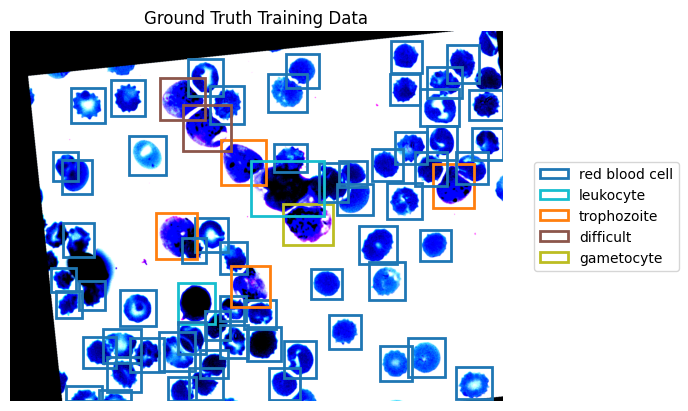

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5354247].


Model set to evaluation mode.


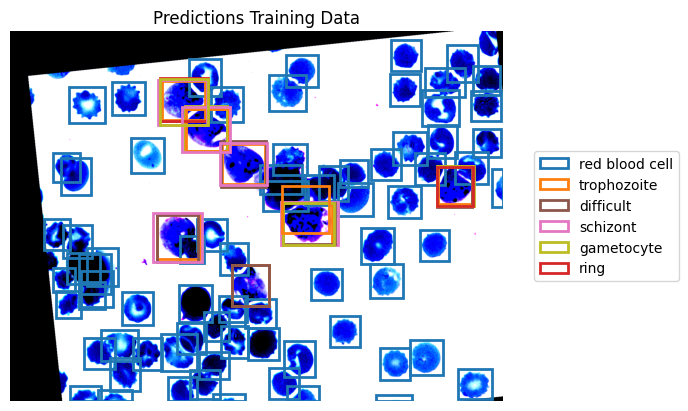

(array([0.9990414 , 0.9988525 , 0.99882585, 0.998659  , 0.9984463 ,
        0.9984005 , 0.9983975 , 0.99832696, 0.9982704 , 0.99824536,
        0.9981437 , 0.99807227, 0.9979918 , 0.9979494 , 0.99788374,
        0.9977701 , 0.9977348 , 0.99754673, 0.99741346, 0.99731195,
        0.99722075, 0.99717355, 0.99700075, 0.99697495, 0.9968131 ,
        0.9967899 , 0.9964696 , 0.9964438 , 0.9960472 , 0.995742  ,
        0.9954978 , 0.995369  , 0.99492586, 0.9944594 , 0.9944411 ,
        0.9939085 , 0.9938822 , 0.9933055 , 0.99167573, 0.99078405,
        0.9901592 , 0.98754394, 0.98537946, 0.9851959 , 0.9843317 ,
        0.97676283, 0.97542477, 0.9644367 , 0.9598013 , 0.9582298 ,
        0.9560347 , 0.9422702 , 0.9347101 , 0.9224448 , 0.9096286 ,
        0.8716832 , 0.8111218 , 0.8086439 , 0.79344   , 0.77685523,
        0.7534033 , 0.7373785 , 0.6244423 , 0.61134434, 0.6108695 ,
        0.58285314, 0.5592362 , 0.553153  , 0.508108  , 0.47360253,
        0.47143963, 0.41524363, 0.41104499, 0.41

In [21]:
# Visualize ground truth 1101, 706, 295, 859, 960, 142, 875, 960, 683, 690
#[3.537180331737787, 1.7466330368058351, 3.5824992875613857, 1.6442612961828798, 4.041775153089522, 1.2420382154541005, 2.913168856020971, 4.041775153089522, 2.2682727718996953, 1.411764703268581]
train_image, target = train_oversampled_dataset[960]
plot_boxes(train_image, target['boxes'], target['labels'], color='g', title='Ground Truth Training Data')

# Visualize predictions (after training)   
malaria_test_model.set_to_evaluation_mode()
with torch.no_grad():
    train_imgage_tensor = train_image.to(device)    
    pred = malaria_test_model.predict(train_imgage_tensor.unsqueeze(0), score_threshold=0.0)[0]

plot_boxes(train_image, pred['boxes'], pred['labels'], color='r', title='Predictions Training Data')
pred['scores'], pred['labels']

### Visualize Ground Truth & Predictions of Test Dataset
This section shows how the AI model "looks" at new malaria cell images it has never seen before. First, we display the correct answers (the real locations and types of cells, marked by experts) on the images. Then, we show what the AI model predicts after learning from the data. By comparing these two sets of boxes, we can easily see how well the model is doing — whether it finds the right cells and if it sometimes misses or mislabels them. This helps us visually check the model's accuracy and understand its strengths and weaknesses in a simple, clear way.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6505601..1.0016558].


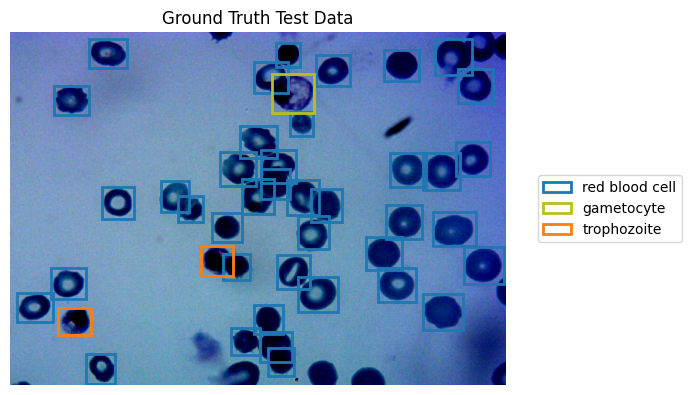

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6505601..1.0016558].


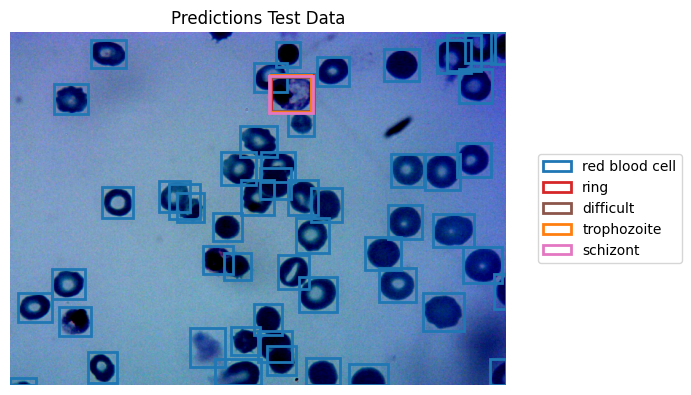

(array([0.9995796 , 0.999549  , 0.99927515, 0.99926823, 0.9990978 ,
        0.9989195 , 0.99891293, 0.9986457 , 0.9986135 , 0.99856216,
        0.9985447 , 0.99846554, 0.9984647 , 0.99773574, 0.99769634,
        0.99743843, 0.99736685, 0.9968342 , 0.99666226, 0.99624276,
        0.996183  , 0.99552095, 0.99534446, 0.9952468 , 0.99509525,
        0.99274147, 0.9920359 , 0.9909237 , 0.99065584, 0.9875459 ,
        0.9857606 , 0.97792065, 0.9729567 , 0.971991  , 0.97028255,
        0.96669567, 0.9460745 , 0.90484345, 0.8962048 , 0.8945338 ,
        0.88789797, 0.74471   , 0.72972417, 0.69766825, 0.68570155,
        0.3885373 , 0.3547009 , 0.28502136, 0.23527285, 0.22261685,
        0.14755319, 0.13344474, 0.13277887, 0.11943918, 0.10968411,
        0.08018689, 0.07493486, 0.05686585], dtype=float32),
 array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 3, 4, 2, 1, 1, 1, 1, 1, 1, 1,

In [22]:
# Visualize ground truth
test_image, target = test_dataset[12]
plot_boxes(test_image, target['boxes'], target['labels'], color='g', title='Ground Truth Test Data')

# Visualize predictions (after training)
with torch.no_grad():
    test_image_tensor = test_image.to(device)    
    pred = malaria_test_model.predict(test_image_tensor.unsqueeze(0), score_threshold=0.0)[0]

plot_boxes(test_image, pred['boxes'], pred['labels'], color='r', title='Predictions Test Data')
pred['scores'], pred['labels']

### Visualize Confusion Matrix for Model Predictions

This section shows "confusion matrix" that helps us see how well the AI model is recognizing different types of malaria cells. The confusion matrix compares the model's predictions to the real answers for each cell type. Each row shows the actual cell type, and each column shows what the model predicted. 

If the model is perfect, all the numbers will be along the diagonal line from top left to bottom right, meaning it always gets the answer right. Numbers away from this line show where the model made mistakes, such as confusing one cell type for another. By looking at this chart, we can quickly spot which cell types the model finds easy or difficult to identify, helping us understand and improve its performance.

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(malaria_model, dataloader, class_names, data=""):
    malaria_model.set_to_evaluation_mode()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for images, targets in dataloader:
            outputs = malaria_model.predict(images, score_threshold=0.0)
            for target, output in zip(targets, outputs):
                pred_labels = output['labels']
                true_labels = target['labels']
                # For confusion matrix, just use all predicted and true labels (flattened)
                y_true.extend(true_labels.tolist())
                y_pred.extend(pred_labels.tolist())
    # Pad y_pred or y_true to have the same length for confusion_matrix
    min_len = min(len(y_true), len(y_pred))
    if len(y_true) != len(y_pred):
        print(f"Warning: y_true and y_pred have different lengths ({len(y_true)} vs {len(y_pred)}). Truncating to {min_len}.")
        y_true = y_true[:min_len]
        y_pred = y_pred[:min_len]
    cm = confusion_matrix(y_true, y_pred, labels=list(range(1, len(class_names)+1)))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names[0:])
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
    plt.title(f'Confusion Matrix {data} Data')
    plt.show()

Model set to evaluation mode.


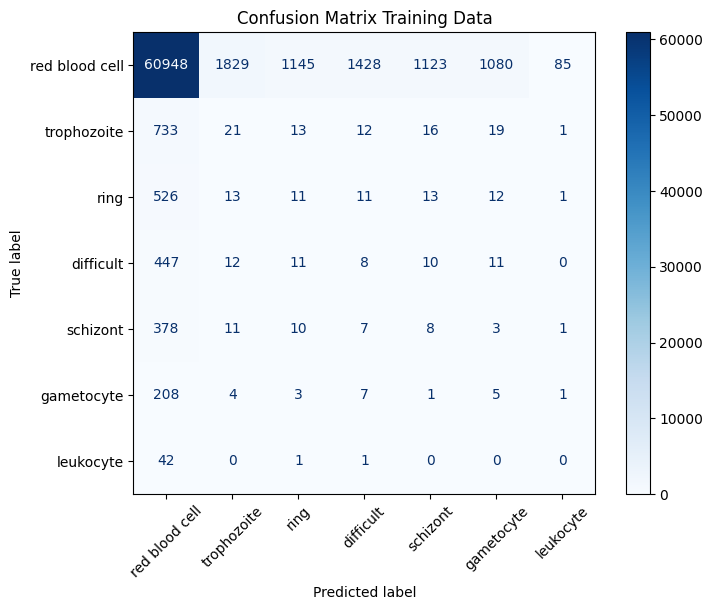

In [24]:
class_names = list(CATEGORY_MAP.keys())
plot_confusion_matrix(malaria_test_model, train_oversampled_data_loader, class_names, data="Training")

Model set to evaluation mode.


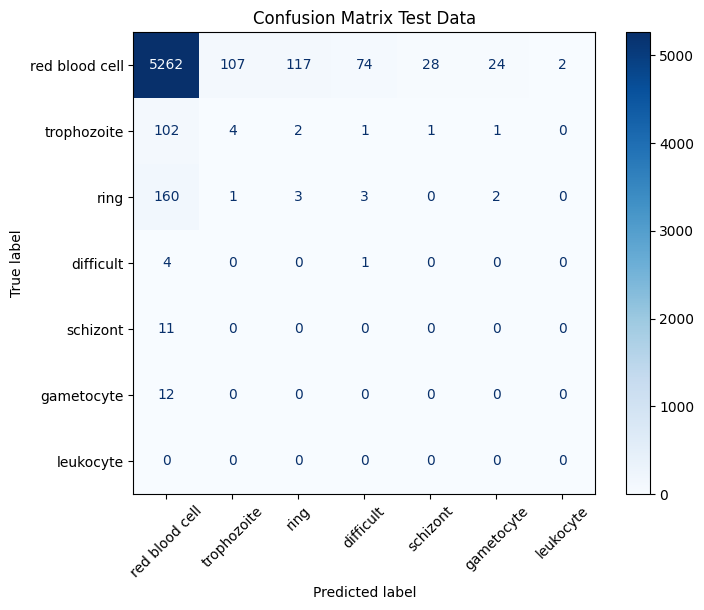

In [25]:
plot_confusion_matrix(malaria_test_model, test_data_loader, class_names, data="Test")

### Visualizing and Filtering Model Predictions for Malaria Cell Detection

The code below shows how the AI model's predictions for malaria cells are displayed and filtered. First, it shows the real locations of cells in a test image, then it shows what the AI model thinks are the cell locations. The code also filters out less confident predictions, so only the most likely cells are shown. This helps us see how well the AI is finding and identifying malaria cells, making it easier to understand the model's strengths and areas for improvement. The results are shown both as images with boxes around the cells and as a simple table listing the predicted cells.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6505601..1.0016558].


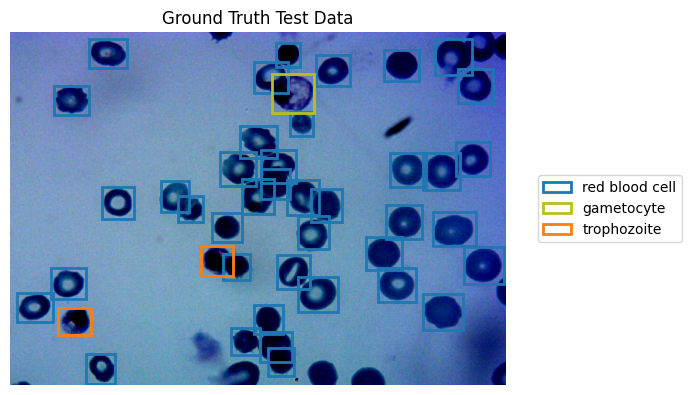

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6505601..1.0016558].


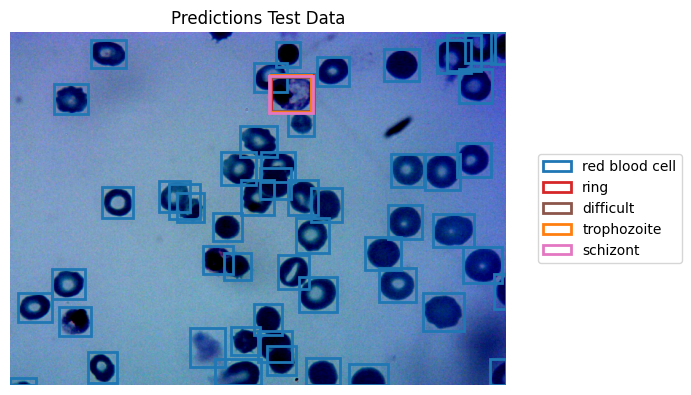

In [30]:
import pandas as pd
import numpy as np

# Visualize ground truth
test_image, target = test_dataset[12]
plot_boxes(test_image, target['boxes'], target['labels'], color='g', title='Ground Truth Test Data')

# Visualize predictions (after training)
with torch.no_grad():
    test_image_tensor = test_image.to(device)    
    pred = malaria_test_model.predict(test_image_tensor.unsqueeze(0), score_threshold=0.0)[0]

plot_boxes(test_image, pred['boxes'], pred['labels'], color='r', title='Predictions Test Data')

### Filtering and Displaying the Most Confident AI Predictions

The code below helps us focus on the most trustworthy malaria cell predictions made by the AI. It first removes overlapping boxes so that each cell is only counted once. Then, it only keeps predictions that the AI is most confident about, especially for rare cell types. This makes the results clearer and more reliable. The filtered predictions are shown both as boxes on the image and as a simple table, making it easy to see which cells the AI has found and how sure it is about each one.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6505601..1.0016558].


Class thresholds: {'red blood cell': 0.6999999998770929, 'trophozoite': 0.023642679014313737, 'ring': 0.03077128606683803, 'difficult': 0.010614535090734853, 'schizont': 0.011351977199616677, 'gametocyte': 0.011474884217763647, 'leukocyte': 0.01}
                                                  box     score  label
0   [1776.325927734375, 843.4597778320312, 1929.58...  0.999580      1
1   [1750.6143798828125, 432.271240234375, 1882.75...  0.999549      1
2   [1479.262451171875, 675.634521484375, 1614.415...  0.999275      1
3   [1657.5086669921875, 713.0122680664062, 1817.3...  0.999268      1
4   [1759.628662109375, 142.96302795410156, 1890.3...  0.999098      1
5   [1617.084228515625, 1023.6656494140625, 1777.4...  0.998919      1
6   [1467.0765380859375, 65.31644439697266, 1601.6...  0.998913      1
7   [1178.2921142578125, 612.2451171875, 1301.3181...  0.998646      1
8   [1133.338623046875, 959.8499145507812, 1281.27...  0.998613      1
9   [1625.8984375, 478.4654846191406, 1762.

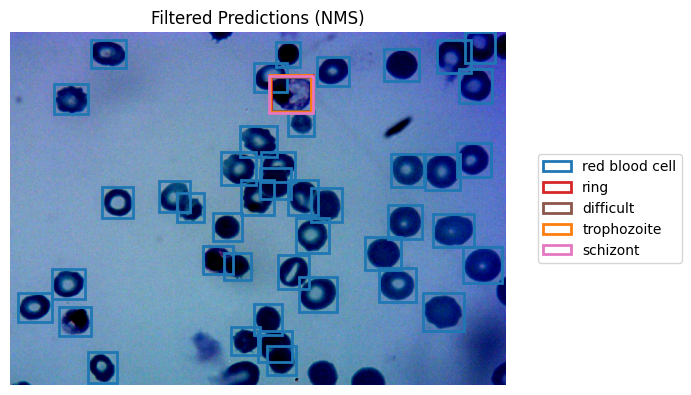

In [31]:
import pandas as pd
# Remove overlapping boxes: keep only the box with the higher score for each overlap

def iou(box1, box2):
    # box: [xmin, ymin, xmax, ymax]
    xA = max(box1[0], box2[0])
    yA = max(box1[1], box2[1])
    xB = min(box1[2], box2[2])
    yB = min(box1[3], box2[3])
    interArea = max(0, xB - xA) * max(0, yB - yA)
    box1Area = max(0, box1[2] - box1[0]) * max(0, box1[3] - box1[1])
    box2Area = max(0, box2[2] - box2[0]) * max(0, box2[3] - box2[1])
    unionArea = box1Area + box2Area - interArea + 1e-6
    return interArea / unionArea if unionArea > 0 else 0

def non_max_suppression(data, iou_threshold=0.5):
    if not data:
        return []
    # Sort by score descending
    data = sorted(data, key=lambda x: x['score'], reverse=True)
    keep = []
    while data:
        best = data.pop(0)
        keep.append(best)
        data = [
            d for d in data
            if iou(best['box'], d['box']) < iou_threshold
        ]
    return keep

# Convert prediction results to a DataFrame for better visualization
boxes = pred['boxes']
scores = pred['scores']
labels = pred['labels']

# Prepare data for the table
data = []
for i in range(len(boxes)):
    box = boxes[i]
    score = scores[i]
    label = labels[i]
    data.append({
        'box': [float(b) for b in box],
        'score': float(score),
        'label': int(label)
    })
   

#data = non_max_suppression(data, iou_threshold=0.95)
# Class distribution (counts)
class_counts, _ = malaria_data_loader.get_class_distribution(test_dataset)
# Map class index to class name (CATEGORY_MAP is already defined above)
idx_to_class = {v: k for k, v in CATEGORY_MAP.items()}
# Compute thresholds: higher for frequent classes, lower for rare classes
max_count = max(class_counts.values())
min_thresh = 0.01
max_thresh = 0.7
# Inverse proportional threshold: rare class -> low threshold, common class -> high threshold
class_thresholds = {}
for class_name, count in class_counts.items():
    # Normalize: 0 for rarest, 1 for most common
    norm = (count - min(class_counts.values())) / (max_count - min(class_counts.values()) + 1e-6)
    # Invert: rarest -> 1, most common -> 0
    #inv_norm = 1 - norm
    # Scale to [min_thresh, max_thresh]
    thresh = min_thresh + norm * (max_thresh - min_thresh)
    class_thresholds[class_name] = thresh

print("Class thresholds:", class_thresholds)

# Filter data by per-class threshold
filtered_data = []
for row in data:
    class_name = idx_to_class.get(row['label'], None)
    if class_name is not None:
        if row['score'] >= class_thresholds[class_name]:
            filtered_data.append(row)
    data = filtered_data
df = pd.DataFrame(data)
print(df)

# Plot filtered boxes on the image
filtered_boxes = np.array([row['box'] for row in data])
filtered_labels = np.array([row['label'] for row in data])
plot_boxes(test_image, filtered_boxes, filtered_labels, color='b', title='Filtered Predictions (NMS)')